# Results per Dataset — Generic Classifier Comparison, SoA Benchmark & Decision Fusion

Fully generic across classifiers, driven entirely by the current `signalai` pipeline output in `results/<DATASET>/<transform>/<classifier>/` — no hardcoded per-run folder names from the legacy notebook.

For every dataset this notebook:
1. Builds the RF / SVM / LGBM x feature-representation result grid straight from the filesystem.
2. Reports a statistical-significance heatmap (CWRU 12K/48K) and a mean +/- std summary table across the whole grid.
3. Finds the single best (classifier, representation) pair and statistically compares it (paired t-test + Wilcoxon) against the state-of-the-art / reference ("IGOR") baseline for that dataset.
4. Runs a **Decision Fusion** suite (majority vote across folds): each classifier alone (fused across every feature representation), every 2-classifier combination (RF+SVM, RF+LGBM, SVM+LGBM), and all three together — each fused across every feature representation too.


In [51]:
import os
import numpy as np
import pandas as pd
from signalai.utils.results import ExperimentResults
from scipy.stats import ttest_rel, wilcoxon, mode
from sklearn.metrics import balanced_accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = "/home/vbbonella/mestrado/tese-mestrado"
RESULTS_ROOT = os.path.join(REPO_ROOT, "results")
# External SoA/reference ("IGOR") baseline CSVs — kept under notebooks/ (not gitignored) so they ship with this notebook.
SOA_ROOT = os.path.join(REPO_ROOT, "notebooks", "soa_baselines")

CLASSIFIERS = ["rf", "svm", "lgbm"]
TRANSFORMS = [
    ("time", "Time"),
    ("frequency", "FFT"),
    ("psd", "PSD"),
    ("wavelet", "Wavelet"),
    ("spectral_envelope", "Envelope"),
    ("time_and_frequency", "T&F"),
    ("all", "All"),
]

# Decision fusion only votes across these 5 ELEMENTARY, independent representations.
# "T&F" and "All" are excluded here because they are themselves concatenations of the
# others -- including them in the vote would double-count the same underlying signal
# and bias the majority vote. They still appear in the comparison table/heatmap/SoA test above.
FUSION_TRANSFORMS = [t for t in TRANSFORMS if t[0] not in ("time_and_frequency", "all")]


In [52]:
def load_experiment_scores(exp_path, metric_name="accuracy"):
    """Loads every round of a multi-round experiment folder and returns one metric value per fold/round."""
    scores = []
    for file in sorted(os.listdir(exp_path)):
        if file.startswith("round") and file.endswith(".json"):
            res = ExperimentResults.load_json(os.path.join(exp_path, file))
            for fold in res.folds:
                scores.append(fold.metrics[metric_name])
    return np.array(scores)


def load_experiment_scores_singleround(exp_path, metric_name="accuracy"):
    """Loads a single-round experiment result file and returns one metric value per fold."""
    res = ExperimentResults.load_json(exp_path)
    return np.array([fold.metrics[metric_name] for fold in res.folds])


def load_scores(exp_path, multi_round, metric_name="accuracy"):
    loader = load_experiment_scores if multi_round else load_experiment_scores_singleround
    return loader(exp_path, metric_name=metric_name)


def get_scores(file_path, metric="f1_macro"):
    """Reads an external SoA-baseline CSV (round, fold, y_true, y_pred) and returns one metric value per round/fold."""
    df = pd.read_csv(file_path)
    scores = []
    for (r, f), group in df.groupby(["round", "fold"]):
        if metric == "f1_macro":
            scores.append(f1_score(group["y_true"], group["y_pred"], average="macro"))
        elif metric == "balanced_acc":
            scores.append(balanced_accuracy_score(group["y_true"], group["y_pred"]))
        else:
            raise ValueError("Metric must be \'f1_macro\' or \'balanced_acc\'")
    return scores


In [53]:
def build_feature_sets(dataset_dir, classifier, multi_round, transforms=TRANSFORMS):
    """{"<CLASSIFIER>\n<Transform>": <absolute result path>} built straight from results/<dataset_dir>/<transform>/<classifier>."""
    entries = {}
    for transform_dir, display_name in transforms:
        path = os.path.join(RESULTS_ROOT, dataset_dir, transform_dir, classifier)
        if not multi_round:
            path = os.path.join(path, "results.json")
        entries[f"{classifier.upper()}\n{display_name}"] = path
    return entries


def build_all_classifiers_feature_sets(dataset_dir, multi_round, transforms=TRANSFORMS, classifiers=CLASSIFIERS):
    combined = {}
    for classifier in classifiers:
        combined.update(build_feature_sets(dataset_dir, classifier, multi_round, transforms))
    return combined


def heatmap_with_statical_test(feature_sets, metric_name="Balanced Accuracy", metric="accuracy", multi_round=True):
    scores_dict = {name: load_scores(path, multi_round, metric_name=metric) for name, path in feature_sets.items()}
    feature_names = list(scores_dict.keys())
    n = len(feature_names)

    stat_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                stat_matrix[i, j] = np.nan  # diagonal
            elif i < j:
                # Upper triangle -> paired t-test
                stat_matrix[i, j] = ttest_rel(scores_dict[feature_names[i]], scores_dict[feature_names[j]]).pvalue
            else:
                # Lower triangle -> Wilcoxon
                stat_matrix[i, j] = wilcoxon(scores_dict[feature_names[i]], scores_dict[feature_names[j]]).pvalue

    stat_df = pd.DataFrame(stat_matrix, index=feature_names, columns=feature_names)
    alpha = 0.05
    mask = stat_df >= alpha
    labels = stat_df.index.tolist()

    plt.figure(figsize=(16, 14))
    sns.heatmap(stat_df, cmap="coolwarm_r", linewidths=0.5, cbar_kws={"label": "p-value"}, mask=mask)
    ax = plt.gca()
    for i, label in enumerate(labels):
        ax.text(i + 0.5, i + 0.5, label, ha="center", va="center", fontsize=8, fontweight="bold", color="black")
    plt.title(
        f"Statistical Comparison of Classifiers x Feature Representations ({metric_name})\n"
        "Upper: paired t-test | Lower: Wilcoxon\n"
        "Only significant differences shown (p < 0.05)",
        fontsize=12,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()


def summarize_feature_sets(feature_sets, multi_round, dataset_label):
    """Mean +/- std F1-Macro / Balanced Accuracy for every (classifier, representation) entry."""
    rows = []
    for name, path in feature_sets.items():
        f1 = load_scores(path, multi_round, metric_name="f1")
        acc = load_scores(path, multi_round, metric_name="accuracy")
        rows.append({
            "Method": name.replace("\n", " "),
            "F1-Macro": f"{np.mean(f1) * 100:.2f} \u00b1 {np.std(f1) * 100:.2f}",
            "Balanced Accuracy": f"{np.mean(acc) * 100:.2f} \u00b1 {np.std(acc) * 100:.2f}",
        })
    df = pd.DataFrame(rows).set_index("Method")
    print(f"--- {dataset_label} ---")
    return df


def best_entry(feature_sets, multi_round, metric_name="f1"):
    """Returns (name, scores) of the (classifier, representation) entry with the highest mean score."""
    best_name, best_scores, best_mean = None, None, -1.0
    for name, path in feature_sets.items():
        scores = load_scores(path, multi_round, metric_name=metric_name)
        m = np.mean(scores)
        if m > best_mean:
            best_name, best_scores, best_mean = name, scores, m
    return best_name, best_scores


def compare_best_to_soa(feature_sets, soa_scores, multi_round, dataset_label):
    """Finds the best (classifier, representation) pair for this dataset and compares it against the SoA baseline."""
    best_name, best_f1 = best_entry(feature_sets, multi_round)
    t_stat, t_pvalue = ttest_rel(best_f1, soa_scores)
    w_stat, w_pvalue = wilcoxon(best_f1, soa_scores)
    print(f"Best method for {dataset_label}: {best_name.strip()} (mean F1-Macro = {np.mean(best_f1):.4f})")
    print(f"T-test vs SoA/reference baseline:   statistic={t_stat:.4f}, p-value={t_pvalue:.4f}")
    print(f"Wilcoxon vs SoA/reference baseline: statistic={w_stat:.4f}, p-value={w_pvalue:.4f}")


In [54]:
def calcular_votacao_majoritaria(dados_entrada):
    """Hard majority vote across models, per round and per fold."""
    resultados_finais = {}
    for round_name, lista_resultados in dados_entrada.items():
        preds_por_fold = {}
        trues_por_fold = {}
        for item in lista_resultados:
            for fold_id, conteudo in item.items():
                if fold_id not in preds_por_fold:
                    preds_por_fold[fold_id] = []
                    trues_por_fold[fold_id] = conteudo["y_true"]
                preds_por_fold[fold_id].append(conteudo["y_pred"])

        resultados_finais[round_name] = {}
        for fold_id, lista_de_preds in preds_por_fold.items():
            matriz_votos = np.array(lista_de_preds)
            resultado_voto, _ = mode(matriz_votos, axis=0, keepdims=False)
            resultados_finais[round_name][fold_id] = {
                "y_pred": resultado_voto.tolist(),
                "y_true": trues_por_fold[fold_id],
            }
    return resultados_finais


def calcular_votacao_confianca(dados_entrada):
    """Confidence-weighted vote: each model votes for its predicted class, but that vote is
    weighted by the model's own confidence (max predicted probability) for that sample, instead
    of every model counting as one equal vote like in `calcular_votacao_majoritaria`."""
    resultados_finais = {}
    for round_name, lista_resultados in dados_entrada.items():
        preds_por_fold = {}
        probas_por_fold = {}
        trues_por_fold = {}
        for item in lista_resultados:
            for fold_id, conteudo in item.items():
                if fold_id not in preds_por_fold:
                    preds_por_fold[fold_id] = []
                    probas_por_fold[fold_id] = []
                    trues_por_fold[fold_id] = conteudo["y_true"]
                preds_por_fold[fold_id].append(conteudo["y_pred"])
                probas_por_fold[fold_id].append(conteudo["y_proba"])

        resultados_finais[round_name] = {}
        for fold_id, lista_de_preds in preds_por_fold.items():
            preds_matrix = np.array(lista_de_preds)  # (n_models, n_samples)
            n_samples = preds_matrix.shape[1]

            # y_proba columns follow each model's sklearn classes_ order (sorted ascending labels
            # seen in ITS training fold), not the raw label values -- e.g. labels {1,2,3} map to
            # columns {0,1,2}. All models here share the same train/test fold split, so they share
            # the same class set; derive the label<->column mapping from the (common) y_true.
            classes = sorted(set(trues_por_fold[fold_id]))
            label_to_col = {label: col for col, label in enumerate(classes)}
            n_classes = len(classes)

            weighted_votes = np.zeros((n_samples, n_classes))
            for pred_m, proba_m in zip(preds_matrix, probas_por_fold[fold_id]):
                proba_m = np.array(proba_m)
                confianca_m = proba_m.max(axis=1)  # model's confidence in its own prediction
                cols_m = np.array([label_to_col[label] for label in pred_m])
                weighted_votes[np.arange(n_samples), cols_m] += confianca_m

            resultado_voto = [classes[col] for col in weighted_votes.argmax(axis=1)]
            resultados_finais[round_name][fold_id] = {
                "y_pred": resultado_voto,
                "y_true": trues_por_fold[fold_id],
            }
    return resultados_finais


def calcular_metricas(dados_votados):
    lista_metricas = []
    for round_name, folds_data in dados_votados.items():
        for fold_id, conteudo in folds_data.items():
            y_true = conteudo["y_true"]
            y_pred = conteudo["y_pred"]
            f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
            bal_acc = balanced_accuracy_score(y_true, y_pred)
            lista_metricas.append({
                "round": round_name, "fold": fold_id, "f1_macro": f1, "balanced_accuracy": bal_acc,
            })
    return lista_metricas


def decision_fusion(exp_paths, multi_round, voting_fn=calcular_votacao_majoritaria):
    """Decision fusion across the given experiment paths (one classifier+representation each).

    `voting_fn` picks the aggregation rule: `calcular_votacao_majoritaria` (default, hard majority
    vote) or `calcular_votacao_confianca` (confidence-weighted vote) -- both consume the same
    per-round/per-fold y_pred/y_true/y_proba structure built below.

    For multi-round datasets, models are grouped by round file name so predictions from every
    exp_path for the SAME round/fold get voted together. Single-round datasets have no such shared
    key across exp_paths (each classifier+representation has its own results.json), so a constant
    key is used instead to force all exp_paths into the same voting group.
    """
    rounds = {}
    for exp_path in exp_paths:
        if multi_round:
            files = [f for f in sorted(os.listdir(exp_path)) if f.startswith("round") and f.endswith(".json")]
            for file in files:
                res = ExperimentResults.load_json(os.path.join(exp_path, file))
                rounds.setdefault(file, [])
                for fold in res.folds:
                    rounds[file].append({fold.fold_index: {"y_pred": fold.y_pred, "y_true": fold.y_true, "y_proba": fold.y_proba}})
        else:
            res = ExperimentResults.load_json(exp_path)
            rounds.setdefault("round0", [])
            for fold in res.folds:
                rounds["round0"].append({fold.fold_index: {"y_pred": fold.y_pred, "y_true": fold.y_true, "y_proba": fold.y_proba}})

    voted = voting_fn(rounds)
    return calcular_metricas(voted)


def run_decision_fusion_suite(fusion_groups, multi_round, dataset_label, voting_fn=calcular_votacao_majoritaria, method_label="Majority Vote"):
    """Runs decision_fusion for every named group of {classifier+representation: path} and tabulates the result."""
    rows = []
    for group_name, feature_sets in fusion_groups.items():
        metrics = decision_fusion(list(feature_sets.values()), multi_round=multi_round, voting_fn=voting_fn)
        f1s = [m["f1_macro"] for m in metrics]
        accs = [m["balanced_accuracy"] for m in metrics]
        rows.append({
            "Fusion Group": group_name,
            "N models": len(feature_sets),
            "F1-Macro": f"{np.mean(f1s) * 100:.2f} ± {np.std(f1s) * 100:.2f}",
            "Balanced Accuracy": f"{np.mean(accs) * 100:.2f} ± {np.std(accs) * 100:.2f}",
        })
    df = pd.DataFrame(rows).set_index("Fusion Group")
    print(f"--- Decision Fusion ({method_label}) — {dataset_label} ---")
    return df


def build_fusion_groups(dataset_dir, multi_round, transforms=FUSION_TRANSFORMS):
    """One classifier alone (fused across all representations), every classifier pair, and all three together."""
    per_classifier = {c: build_feature_sets(dataset_dir, c, multi_round, transforms) for c in CLASSIFIERS}
    rf, svm, lgbm = per_classifier["rf"], per_classifier["svm"], per_classifier["lgbm"]
    return {
        "RF": rf,
        "SVM": svm,
        "LGBM": lgbm,
        "RF+SVM": {**rf, **svm},
        "RF+LGBM": {**rf, **lgbm},
        "SVM+LGBM": {**svm, **lgbm},
        "RF+SVM+LGBM": {**rf, **svm, **lgbm},
    }


def run_decision_fusion_ablation(dataset_dir, multi_round):
    """Leave-one-representation-out ablation for every fusion group: Delta F1-Macro (pp) when
    each elementary representation is removed from that group's majority vote, vs. the full
    (all 5 representations) fusion. Positive Delta = removing it hurt the fusion."""
    fusion_groups = build_fusion_groups(dataset_dir, multi_round)
    rows = []
    for group_name, feature_sets in fusion_groups.items():
        baseline_metrics = decision_fusion(list(feature_sets.values()), multi_round=multi_round)
        baseline_f1 = np.mean([m["f1_macro"] for m in baseline_metrics])
        for _, removed_display in FUSION_TRANSFORMS:
            ablated_sets = {k: v for k, v in feature_sets.items() if not k.endswith(f"\n{removed_display}")}
            ablated_metrics = decision_fusion(list(ablated_sets.values()), multi_round=multi_round)
            ablated_f1 = np.mean([m["f1_macro"] for m in ablated_metrics])
            rows.append({
                "Fusion Group": group_name,
                "Removed": removed_display,
                "Delta F1": (baseline_f1 - ablated_f1) * 100,
            })
    return pd.DataFrame(rows)


def plot_fusion_ablation_heatmap(ablation_df, group_name):
    subset = ablation_df[ablation_df["Fusion Group"] == group_name]
    pivot = subset.pivot(index="Dataset", columns="Removed", values="Delta F1")
    order = [display for _, display in FUSION_TRANSFORMS]
    pivot = pivot[[c for c in order if c in pivot.columns]]

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
        cbar_kws={"label": "Δ F1-Macro (pp) when removed"},
    )
    plt.title(f"Decision Fusion Ablation — {group_name}\nPositive = removing this representation hurt the fusion")
    plt.xlabel("Removed representation")
    plt.ylabel("Dataset")
    plt.tight_layout()
    plt.show()


## CWRU 12K

In [55]:
NEW_DATASET_DIR_CWRU12K = "CWRU_12K"
MULTI_ROUND_CWRU12K = True

feature_sets_cwru12k = build_all_classifiers_feature_sets(NEW_DATASET_DIR_CWRU12K, MULTI_ROUND_CWRU12K)


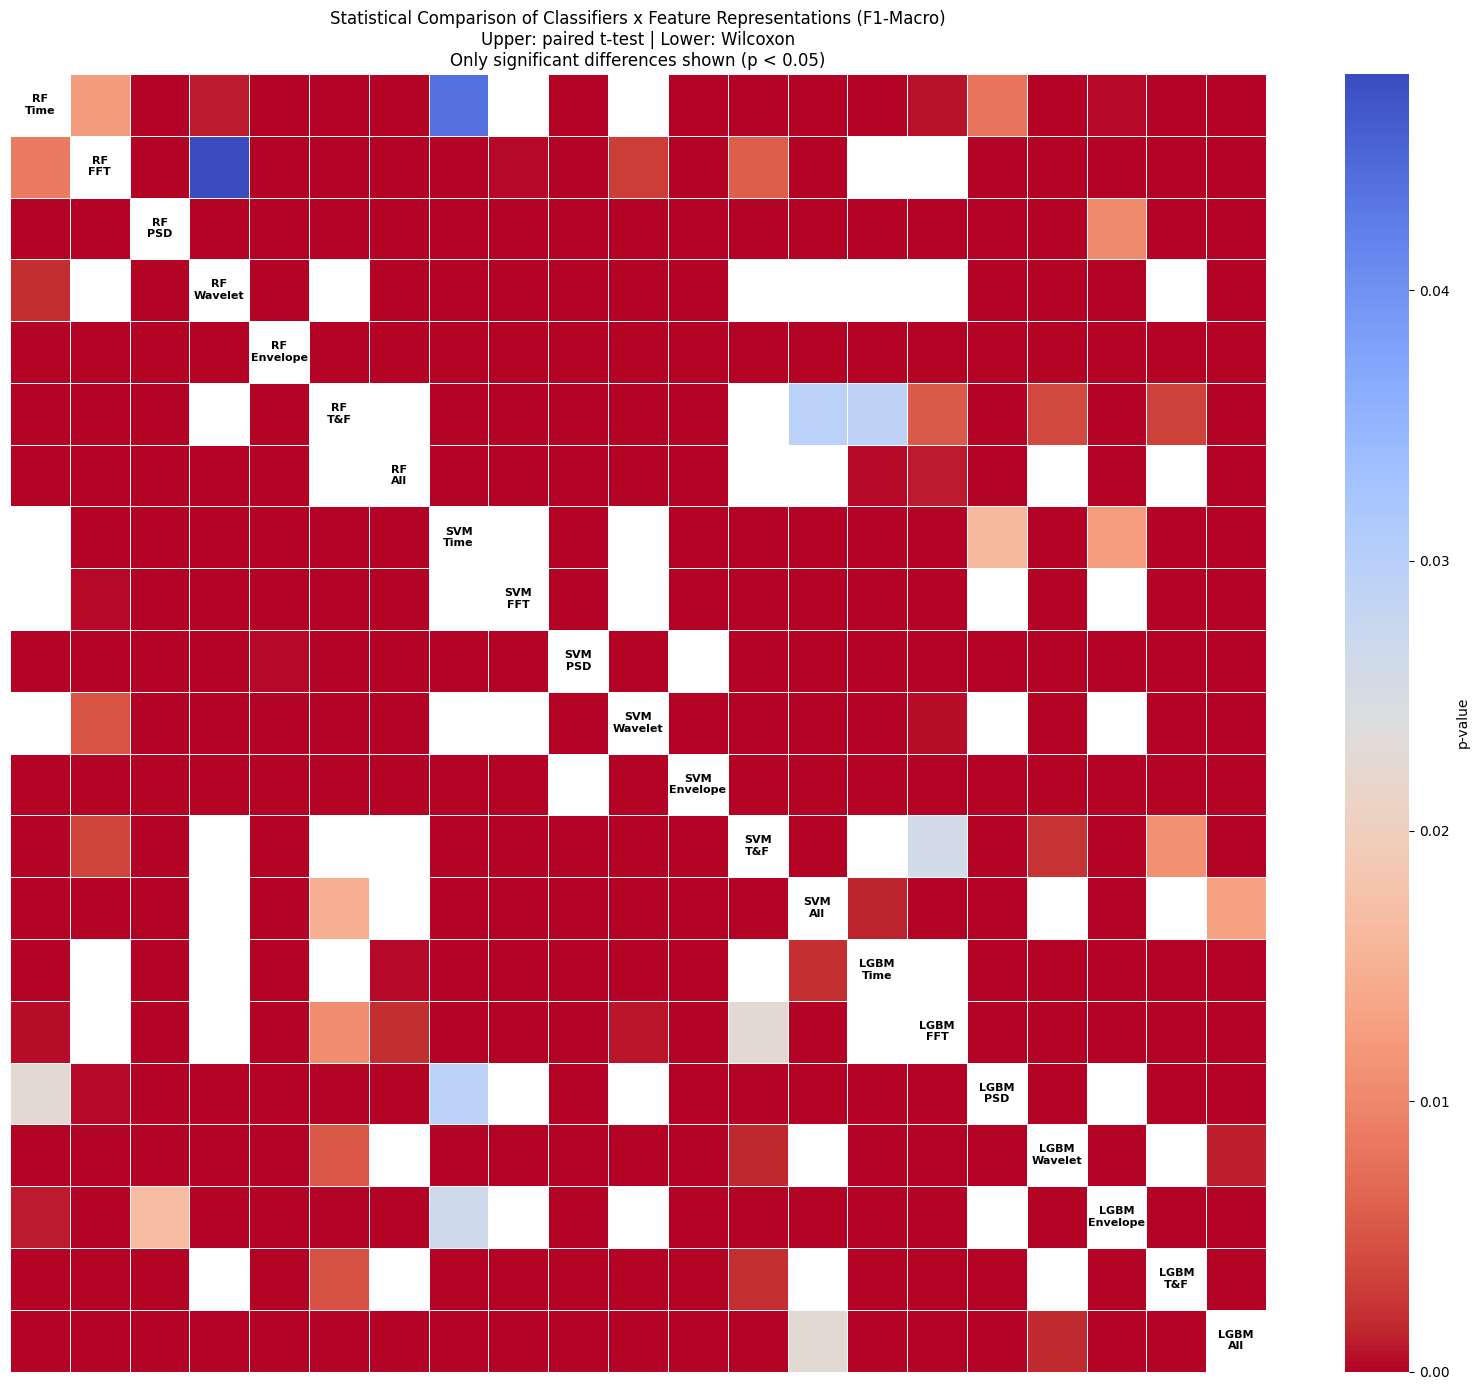

In [56]:
heatmap_with_statical_test(feature_sets_cwru12k, metric_name="F1-Macro", metric="f1", multi_round=MULTI_ROUND_CWRU12K)

In [57]:
summarize_feature_sets(feature_sets_cwru12k, multi_round=MULTI_ROUND_CWRU12K, dataset_label="CWRU 12K")

--- CWRU 12K ---


,F1-Macro,Balanced Accuracy
Method,,
RF Time,84.10 ± 3.83,84.17 ± 3.84
RF FFT,85.41 ± 5.09,85.60 ± 5.04
RF PSD,79.39 ± 5.78,79.51 ± 5.52
RF Wavelet,87.16 ± 4.95,87.31 ± 4.87
RF Envelope,76.00 ± 4.10,76.01 ± 3.99
RF T&F,87.53 ± 4.06,87.69 ± 4.00
RF All,88.70 ± 4.49,88.77 ± 4.50
SVM Time,83.18 ± 4.86,83.91 ± 4.83
SVM FFT,82.46 ± 7.33,82.84 ± 7.21


In [ ]:
soa_scores_cwru12k = [
    0.7902770056, 0.9439482654, 0.9847199068, 0.9114802019, 0.887644941,
    0.8467578272, 0.9662537917, 0.8196774822, 0.786926682, 0.9833250988,
    0.8670943029, 0.9005406266, 0.9344792401, 0.8537185629, 0.8033588429,
    0.9211803071, 0.980891957, 0.7917359036, 0.7920137189, 0.9551105579,
    0.9248729984, 0.8853768775, 0.848056934, 0.8614514026, 0.9082609495,
    0.7702018, 0.9507637332, 0.8768043408, 0.837433728, 0.8542860028,
    0.9261553806, 0.9272405031,
]
print(np.mean(soa_scores_cwru12k))
compare_best_to_soa(feature_sets_cwru12k, soa_scores_cwru12k, multi_round=MULTI_ROUND_CWRU12K, dataset_label="CWRU 12K")

0.88412624603125


In [59]:
fusion_groups_cwru12k = build_fusion_groups(NEW_DATASET_DIR_CWRU12K, MULTI_ROUND_CWRU12K)
run_decision_fusion_suite(fusion_groups_cwru12k, multi_round=MULTI_ROUND_CWRU12K, dataset_label="CWRU 12K")

--- Decision Fusion (Majority Vote) — CWRU 12K ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,87.42 ± 4.16,87.53 ± 4.10
SVM,5,85.20 ± 7.03,85.71 ± 6.60
LGBM,5,89.30 ± 4.11,89.43 ± 3.99
RF+SVM,10,88.27 ± 5.23,88.50 ± 5.07
RF+LGBM,10,89.14 ± 4.07,89.28 ± 3.97
SVM+LGBM,10,89.15 ± 5.20,89.38 ± 4.99
RF+SVM+LGBM,15,89.34 ± 4.18,89.50 ± 4.07


In [60]:
run_decision_fusion_suite(fusion_groups_cwru12k, multi_round=MULTI_ROUND_CWRU12K, dataset_label="CWRU 12K", voting_fn=calcular_votacao_confianca, method_label="Confidence-Weighted Vote")

--- Decision Fusion (Confidence-Weighted Vote) — CWRU 12K ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,87.63 ± 4.20,87.71 ± 4.13
SVM,5,87.14 ± 5.80,87.36 ± 5.69
LGBM,5,89.32 ± 4.08,89.43 ± 3.99
RF+SVM,10,88.99 ± 4.80,89.15 ± 4.73
RF+LGBM,10,89.07 ± 4.01,89.18 ± 3.93
SVM+LGBM,10,90.01 ± 4.50,90.16 ± 4.37
RF+SVM+LGBM,15,89.70 ± 4.07,89.83 ± 3.97


## CWRU 48K

In [61]:
NEW_DATASET_DIR_CWRU48K = "CWRU_48K"
MULTI_ROUND_CWRU48K = True

feature_sets_cwru48k = build_all_classifiers_feature_sets(NEW_DATASET_DIR_CWRU48K, MULTI_ROUND_CWRU48K)


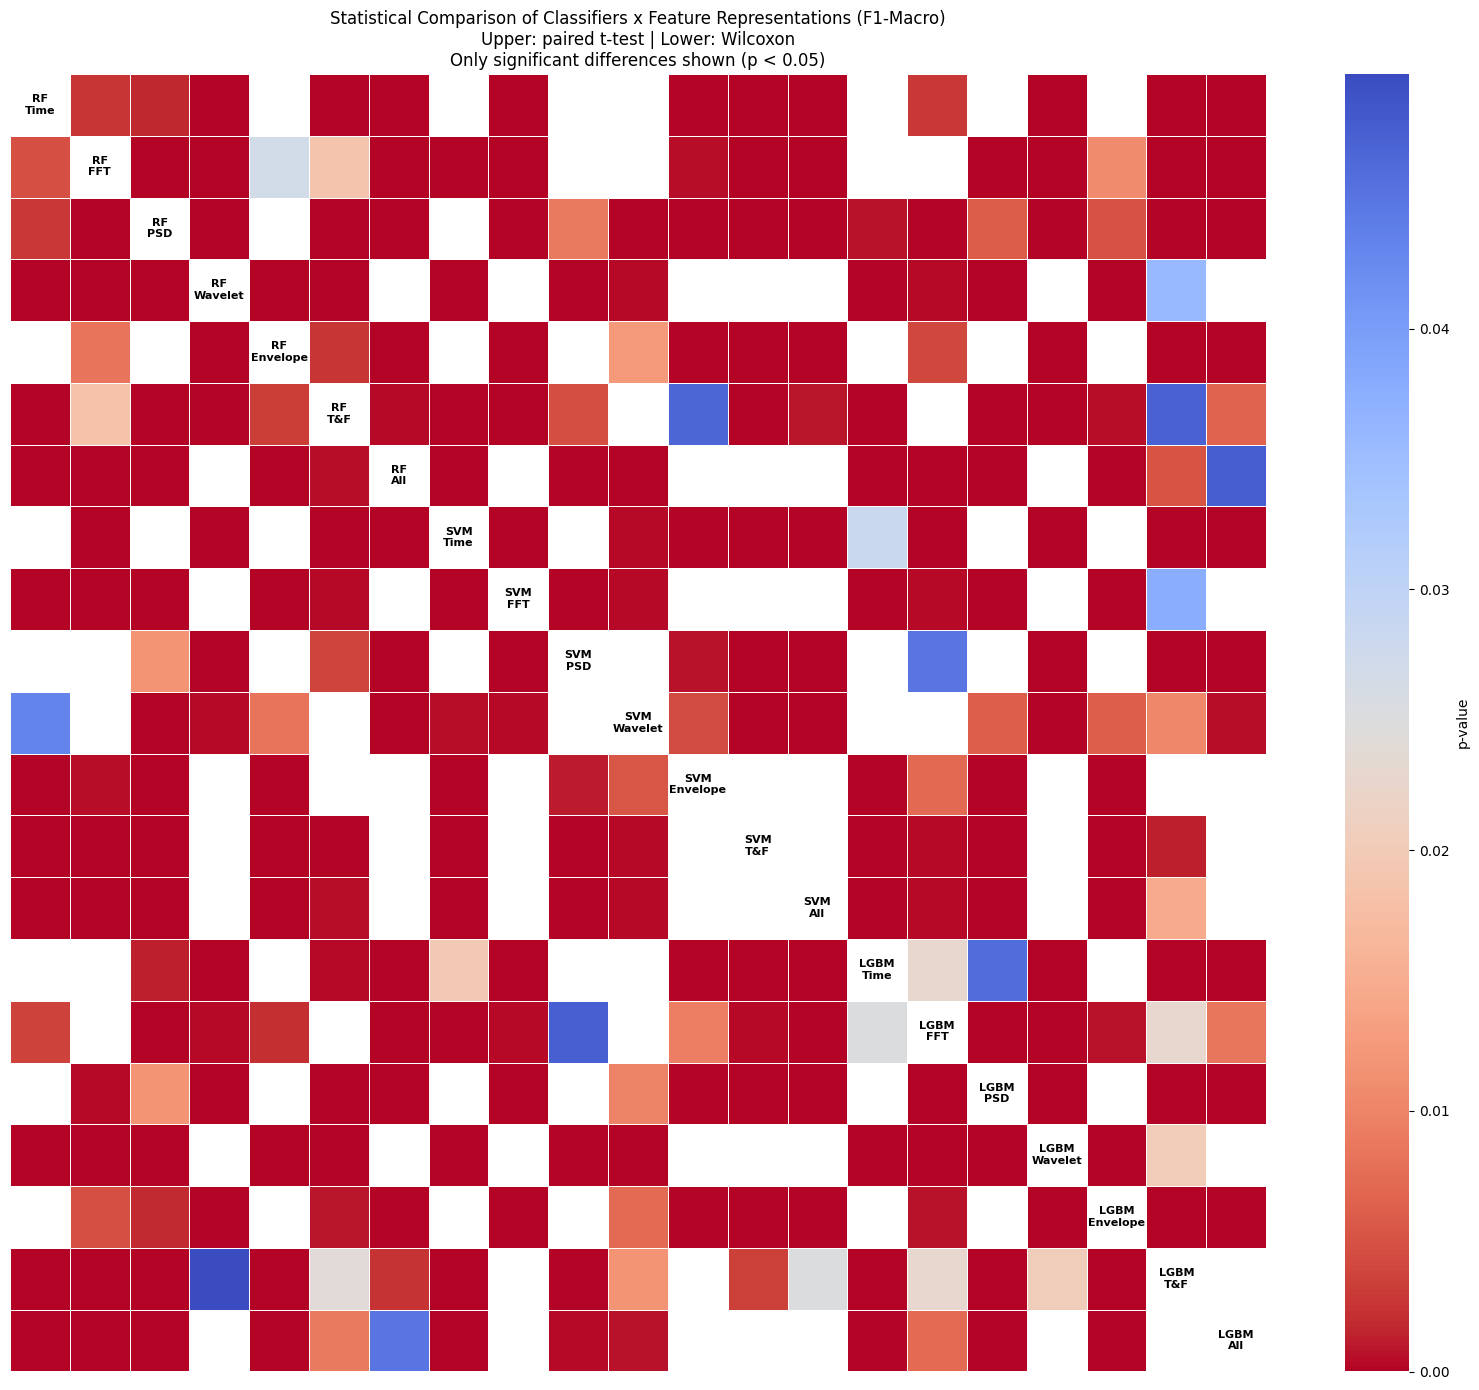

In [62]:
heatmap_with_statical_test(feature_sets_cwru48k, metric_name="F1-Macro", metric="f1", multi_round=MULTI_ROUND_CWRU48K)

In [63]:
summarize_feature_sets(feature_sets_cwru48k, multi_round=MULTI_ROUND_CWRU48K, dataset_label="CWRU 48K")

--- CWRU 48K ---


,F1-Macro,Balanced Accuracy
Method,,
RF Time,77.44 ± 7.34,78.52 ± 6.92
RF FFT,80.54 ± 7.07,80.16 ± 7.67
RF PSD,73.55 ± 6.96,73.34 ± 7.04
RF Wavelet,87.24 ± 6.29,86.95 ± 6.71
RF Envelope,76.60 ± 10.05,77.45 ± 9.62
RF T&F,82.68 ± 7.06,83.06 ± 6.95
RF All,87.88 ± 8.84,88.25 ± 8.40
SVM Time,74.76 ± 11.46,75.87 ± 11.46
SVM FFT,86.52 ± 8.54,86.55 ± 8.23


In [64]:
soa_scores_cwru48k = get_scores(os.path.join(SOA_ROOT, "results-baselines-cwru-48k-randomforest-multirounds-2024-08-02T21_06_17.619194.csv"), metric="f1_macro")
compare_best_to_soa(feature_sets_cwru48k, soa_scores_cwru48k, multi_round=MULTI_ROUND_CWRU48K, dataset_label="CWRU 48K")

Best method for CWRU 48K: RF
All (mean F1-Macro = 0.8788)
T-test vs SoA/reference baseline:   statistic=6.0047, p-value=0.0000
Wilcoxon vs SoA/reference baseline: statistic=38.0000, p-value=0.0000


In [65]:
fusion_groups_cwru48k = build_fusion_groups(NEW_DATASET_DIR_CWRU48K, MULTI_ROUND_CWRU48K)
run_decision_fusion_suite(fusion_groups_cwru48k, multi_round=MULTI_ROUND_CWRU48K, dataset_label="CWRU 48K")

--- Decision Fusion (Majority Vote) — CWRU 48K ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,83.73 ± 5.88,83.97 ± 5.99
SVM,5,87.49 ± 8.37,87.84 ± 8.33
LGBM,5,84.54 ± 8.09,84.62 ± 8.15
RF+SVM,10,87.41 ± 7.35,87.76 ± 7.11
RF+LGBM,10,84.71 ± 6.81,84.95 ± 6.81
SVM+LGBM,10,88.94 ± 7.87,89.10 ± 7.68
RF+SVM+LGBM,15,86.85 ± 7.12,87.09 ± 6.96


In [66]:
run_decision_fusion_suite(fusion_groups_cwru48k, multi_round=MULTI_ROUND_CWRU48K, dataset_label="CWRU 48K", voting_fn=calcular_votacao_confianca, method_label="Confidence-Weighted Vote")

--- Decision Fusion (Confidence-Weighted Vote) — CWRU 48K ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,85.18 ± 6.33,85.44 ± 6.23
SVM,5,88.97 ± 8.11,89.05 ± 7.99
LGBM,5,84.90 ± 7.53,84.88 ± 7.48
RF+SVM,10,88.22 ± 7.56,88.46 ± 7.23
RF+LGBM,10,85.12 ± 6.75,85.31 ± 6.50
SVM+LGBM,10,89.24 ± 8.00,89.38 ± 7.75
RF+SVM+LGBM,15,87.52 ± 7.50,87.74 ± 7.28


## IMS

In [67]:
NEW_DATASET_DIR_IMS = "IMS"
MULTI_ROUND_IMS = False

feature_sets_ims = build_all_classifiers_feature_sets(NEW_DATASET_DIR_IMS, MULTI_ROUND_IMS)


In [68]:
summarize_feature_sets(feature_sets_ims, multi_round=MULTI_ROUND_IMS, dataset_label="IMS")

--- IMS ---


,F1-Macro,Balanced Accuracy
Method,,
RF Time,12.15 ± 1.16,18.27 ± 1.73
RF FFT,14.36 ± 1.32,19.98 ± 1.81
RF PSD,15.57 ± 2.07,20.87 ± 1.99
RF Wavelet,10.59 ± 0.79,17.48 ± 0.69
RF Envelope,15.72 ± 1.66,20.96 ± 1.93
RF T&F,11.59 ± 1.25,18.20 ± 1.49
RF All,11.55 ± 1.50,18.11 ± 1.54
SVM Time,8.61 ± 0.27,16.15 ± 0.53
SVM FFT,5.58 ± 1.11,14.81 ± 0.18


In [69]:
soa_scores_ims = [0.2135435477, 0.224396093, 0.2066412528]
compare_best_to_soa(feature_sets_ims, soa_scores_ims, multi_round=MULTI_ROUND_IMS, dataset_label="IMS")

Best method for IMS: LGBM
PSD (mean F1-Macro = 0.1757)
T-test vs SoA/reference baseline:   statistic=-5.5119, p-value=0.0314
Wilcoxon vs SoA/reference baseline: statistic=0.0000, p-value=0.2500


In [70]:
fusion_groups_ims = build_fusion_groups(NEW_DATASET_DIR_IMS, MULTI_ROUND_IMS)
run_decision_fusion_suite(fusion_groups_ims, multi_round=MULTI_ROUND_IMS, dataset_label="IMS")

--- Decision Fusion (Majority Vote) — IMS ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,9.51 ± 0.97,16.80 ± 1.02
SVM,5,4.97 ± 0.93,14.42 ± 0.05
LGBM,5,11.43 ± 1.76,18.06 ± 1.20
RF+SVM,10,5.01 ± 1.04,14.46 ± 0.07
RF+LGBM,10,8.80 ± 0.66,16.34 ± 0.75
SVM+LGBM,10,5.25 ± 1.05,14.51 ± 0.04
RF+SVM+LGBM,15,6.80 ± 0.88,15.29 ± 0.34


In [71]:
run_decision_fusion_suite(fusion_groups_ims, multi_round=MULTI_ROUND_IMS, dataset_label="IMS", voting_fn=calcular_votacao_confianca, method_label="Confidence-Weighted Vote")

--- Decision Fusion (Confidence-Weighted Vote) — IMS ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,10.04 ± 0.93,17.10 ± 1.15
SVM,5,4.93 ± 0.92,14.38 ± 0.05
LGBM,5,11.82 ± 1.56,18.31 ± 1.15
RF+SVM,10,5.41 ± 1.01,14.58 ± 0.06
RF+LGBM,10,10.07 ± 1.10,17.09 ± 1.11
SVM+LGBM,10,6.56 ± 1.12,15.11 ± 0.33
RF+SVM+LGBM,15,7.26 ± 0.89,15.50 ± 0.48


## MFPT

In [72]:
NEW_DATASET_DIR_MFPT = "MFPT"
MULTI_ROUND_MFPT = True

feature_sets_mfpt = build_all_classifiers_feature_sets(NEW_DATASET_DIR_MFPT, MULTI_ROUND_MFPT)


In [73]:
summarize_feature_sets(feature_sets_mfpt, multi_round=MULTI_ROUND_MFPT, dataset_label="MFPT")

--- MFPT ---


,F1-Macro,Balanced Accuracy
Method,,
RF Time,92.14 ± 19.99,93.81 ± 15.47
RF FFT,90.48 ± 23.33,92.86 ± 17.50
RF PSD,95.22 ± 12.10,95.71 ± 10.80
RF Wavelet,82.86 ± 29.14,87.14 ± 21.85
RF Envelope,71.31 ± 33.96,77.62 ± 27.30
RF T&F,90.48 ± 23.33,92.86 ± 17.50
RF All,86.19 ± 24.60,89.05 ± 19.08
SVM Time,100.00 ± 0.00,100.00 ± 0.00
SVM FFT,90.48 ± 23.33,92.86 ± 17.50


In [74]:
soa_scores_mfpt = get_scores(os.path.join(SOA_ROOT, "results-baselines-mfpt-48k-1nn-multirounds-2024-08-02T20_05_31.922627.csv"), metric="f1_macro")
compare_best_to_soa(feature_sets_mfpt, soa_scores_mfpt, multi_round=MULTI_ROUND_MFPT, dataset_label="MFPT")

Best method for MFPT: SVM
Time (mean F1-Macro = 1.0000)
T-test vs SoA/reference baseline:   statistic=1.9475, p-value=0.0598
Wilcoxon vs SoA/reference baseline: statistic=0.0000, p-value=0.0633


In [75]:
fusion_groups_mfpt = build_fusion_groups(NEW_DATASET_DIR_MFPT, MULTI_ROUND_MFPT)
run_decision_fusion_suite(fusion_groups_mfpt, multi_round=MULTI_ROUND_MFPT, dataset_label="MFPT")

--- Decision Fusion (Majority Vote) — MFPT ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,91.31 ± 21.74,93.33 ± 16.52
SVM,5,99.51 ± 2.86,99.52 ± 2.78
LGBM,5,95.22 ± 12.10,95.71 ± 10.80
RF+SVM,10,91.31 ± 21.74,93.33 ± 16.52
RF+LGBM,10,91.31 ± 21.74,93.33 ± 16.52
SVM+LGBM,10,95.22 ± 12.10,95.71 ± 10.80
RF+SVM+LGBM,15,91.89 ± 21.23,93.81 ± 15.98


In [76]:
run_decision_fusion_suite(fusion_groups_mfpt, multi_round=MULTI_ROUND_MFPT, dataset_label="MFPT", voting_fn=calcular_votacao_confianca, method_label="Confidence-Weighted Vote")

--- Decision Fusion (Confidence-Weighted Vote) — MFPT ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,90.48 ± 23.33,92.86 ± 17.50
SVM,5,99.51 ± 2.86,99.52 ± 2.78
LGBM,5,95.22 ± 12.10,95.71 ± 10.80
RF+SVM,10,91.31 ± 21.74,93.33 ± 16.52
RF+LGBM,10,91.31 ± 21.74,93.33 ± 16.52
SVM+LGBM,10,95.22 ± 12.10,95.71 ± 10.80
RF+SVM+LGBM,15,91.31 ± 21.74,93.33 ± 16.52


## PU

In [77]:
NEW_DATASET_DIR_PU = "PU"
MULTI_ROUND_PU = True

feature_sets_pu = build_all_classifiers_feature_sets(NEW_DATASET_DIR_PU, MULTI_ROUND_PU)


In [78]:
summarize_feature_sets(feature_sets_pu, multi_round=MULTI_ROUND_PU, dataset_label="PU")

--- PU ---


,F1-Macro,Balanced Accuracy
Method,,
RF Time,64.64 ± 22.02,69.11 ± 17.61
RF FFT,64.70 ± 22.01,68.46 ± 18.76
RF PSD,61.45 ± 21.96,66.45 ± 18.38
RF Wavelet,69.97 ± 22.86,73.21 ± 19.02
RF Envelope,55.56 ± 18.00,57.11 ± 15.66
RF T&F,68.11 ± 21.90,72.24 ± 17.73
RF All,69.96 ± 23.45,73.48 ± 18.98
SVM Time,59.35 ± 20.53,63.75 ± 17.98
SVM FFT,65.80 ± 21.11,70.14 ± 17.33


In [79]:
soa_scores_pu = get_scores(os.path.join(SOA_ROOT, "results-baselines-pu-randomforest-multirounds-2024-08-02T20_37_00.213897.csv"), metric="f1_macro")
compare_best_to_soa(feature_sets_pu, soa_scores_pu, multi_round=MULTI_ROUND_PU, dataset_label="PU")

Best method for PU: LGBM
Wavelet (mean F1-Macro = 0.7083)
T-test vs SoA/reference baseline:   statistic=2.1775, p-value=0.0372
Wilcoxon vs SoA/reference baseline: statistic=156.0000, p-value=0.0433


In [80]:
fusion_groups_pu = build_fusion_groups(NEW_DATASET_DIR_PU, MULTI_ROUND_PU)
run_decision_fusion_suite(fusion_groups_pu, multi_round=MULTI_ROUND_PU, dataset_label="PU")

--- Decision Fusion (Majority Vote) — PU ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,67.37 ± 23.28,71.24 ± 19.18
SVM,5,65.11 ± 22.55,69.73 ± 18.61
LGBM,5,68.13 ± 22.44,71.38 ± 19.06
RF+SVM,10,67.76 ± 23.58,72.12 ± 19.09
RF+LGBM,10,68.19 ± 22.60,71.69 ± 18.89
SVM+LGBM,10,67.49 ± 23.42,71.69 ± 19.30
RF+SVM+LGBM,15,68.05 ± 23.61,72.11 ± 19.36


In [81]:
run_decision_fusion_suite(fusion_groups_pu, multi_round=MULTI_ROUND_PU, dataset_label="PU", voting_fn=calcular_votacao_confianca, method_label="Confidence-Weighted Vote")

--- Decision Fusion (Confidence-Weighted Vote) — PU ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,67.25 ± 22.81,70.94 ± 19.02
SVM,5,65.71 ± 22.55,70.37 ± 18.73
LGBM,5,67.92 ± 22.66,71.32 ± 19.22
RF+SVM,10,67.59 ± 23.62,72.04 ± 19.36
RF+LGBM,10,68.00 ± 22.87,71.45 ± 19.30
SVM+LGBM,10,67.95 ± 23.13,71.96 ± 19.27
RF+SVM+LGBM,15,68.13 ± 23.37,72.13 ± 19.33


## UOC

In [82]:
NEW_DATASET_DIR_UOC = "UOC"
MULTI_ROUND_UOC = False

feature_sets_uoc = build_all_classifiers_feature_sets(NEW_DATASET_DIR_UOC, MULTI_ROUND_UOC)


In [83]:
summarize_feature_sets(feature_sets_uoc, multi_round=MULTI_ROUND_UOC, dataset_label="UOC")

--- UOC ---


,F1-Macro,Balanced Accuracy
Method,,
RF Time,88.04 ± 13.50,92.81 ± 8.11
RF FFT,88.51 ± 14.01,92.89 ± 8.30
RF PSD,96.76 ± 3.27,98.47 ± 1.48
RF Wavelet,84.13 ± 18.17,91.77 ± 9.54
RF Envelope,84.32 ± 12.11,89.85 ± 7.96
RF T&F,89.88 ± 11.86,93.47 ± 7.30
RF All,85.05 ± 15.99,91.50 ± 9.43
SVM Time,88.85 ± 12.80,93.70 ± 7.77
SVM FFT,92.93 ± 13.60,95.92 ± 7.96


In [84]:
soa_scores_uoc = [0.9889673433, 1, 1, 1, 0.6679525419]
compare_best_to_soa(feature_sets_uoc, soa_scores_uoc, multi_round=MULTI_ROUND_UOC, dataset_label="UOC")

Best method for UOC: RF
PSD (mean F1-Macro = 0.9676)
T-test vs SoA/reference baseline:   statistic=0.4831, p-value=0.6543
Wilcoxon vs SoA/reference baseline: statistic=4.0000, p-value=0.8750


In [85]:
fusion_groups_uoc = build_fusion_groups(NEW_DATASET_DIR_UOC, MULTI_ROUND_UOC)
run_decision_fusion_suite(fusion_groups_uoc, multi_round=MULTI_ROUND_UOC, dataset_label="UOC")

--- Decision Fusion (Majority Vote) — UOC ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,91.14 ± 14.04,95.23 ± 7.66
SVM,5,92.70 ± 13.48,95.85 ± 7.92
LGBM,5,89.82 ± 14.86,95.08 ± 7.48
RF+SVM,10,92.80 ± 13.32,95.88 ± 7.85
RF+LGBM,10,90.87 ± 12.69,95.23 ± 7.10
SVM+LGBM,10,92.41 ± 13.19,95.73 ± 7.79
RF+SVM+LGBM,15,92.50 ± 13.21,95.77 ± 7.80


In [86]:
run_decision_fusion_suite(fusion_groups_uoc, multi_round=MULTI_ROUND_UOC, dataset_label="UOC", voting_fn=calcular_votacao_confianca, method_label="Confidence-Weighted Vote")

--- Decision Fusion (Confidence-Weighted Vote) — UOC ---


,N models,F1-Macro,Balanced Accuracy
Fusion Group,,,
RF,5,92.20 ± 11.96,95.50 ± 7.13
SVM,5,93.01 ± 13.42,95.96 ± 7.89
LGBM,5,90.48 ± 13.70,95.19 ± 7.33
RF+SVM,10,93.12 ± 13.48,96.00 ± 7.90
RF+LGBM,10,92.55 ± 12.34,95.85 ± 7.29
SVM+LGBM,10,93.01 ± 13.42,95.96 ± 7.89
RF+SVM+LGBM,15,92.70 ± 13.28,95.85 ± 7.83


## Decision Fusion Ablation (leave-one-representation-out)

Same idea as `dashboard/fig_ablation_heatmap` (leave-one-feature-group-out for *feature-level* fusion), applied to *decision-level* fusion instead: for every fusion group, each of the 5 elementary representations is removed from the majority vote in turn, and the resulting drop in F1-Macro is measured against the full 5-representation fusion, for every dataset.

In [87]:
DATASET_CONFIGS = [
    ("CWRU 12K", NEW_DATASET_DIR_CWRU12K, MULTI_ROUND_CWRU12K),
    ("CWRU 48K", NEW_DATASET_DIR_CWRU48K, MULTI_ROUND_CWRU48K),
    ("IMS", NEW_DATASET_DIR_IMS, MULTI_ROUND_IMS),
    ("MFPT", NEW_DATASET_DIR_MFPT, MULTI_ROUND_MFPT),
    ("PU", NEW_DATASET_DIR_PU, MULTI_ROUND_PU),
    ("UOC", NEW_DATASET_DIR_UOC, MULTI_ROUND_UOC),
]

In [88]:
fusion_ablation_frames = []
for dataset_label, dataset_dir, multi_round in DATASET_CONFIGS:
    df = run_decision_fusion_ablation(dataset_dir, multi_round)
    df["Dataset"] = dataset_label
    fusion_ablation_frames.append(df)

fusion_ablation_df = pd.concat(fusion_ablation_frames, ignore_index=True)
fusion_ablation_df


,Fusion Group,Removed,Delta F1,Dataset
0,RF,Time,0.875194,CWRU 12K
1,RF,FFT,0.888982,CWRU 12K
2,RF,PSD,-0.752592,CWRU 12K
3,RF,Wavelet,2.087743,CWRU 12K
4,RF,Envelope,-0.192474,CWRU 12K
...,...,...,...,...
205,RF+SVM+LGBM,Time,0.131697,UOC
206,RF+SVM+LGBM,FFT,0.846698,UOC
207,RF+SVM+LGBM,PSD,0.388366,UOC
208,RF+SVM+LGBM,Wavelet,2.003746,UOC


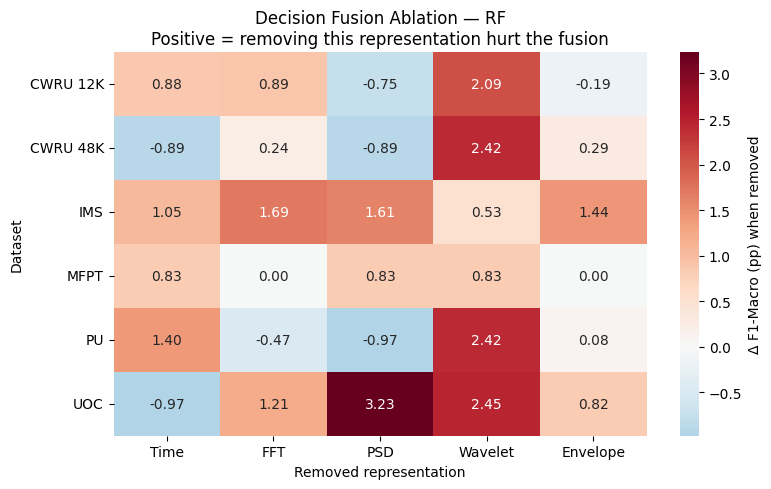

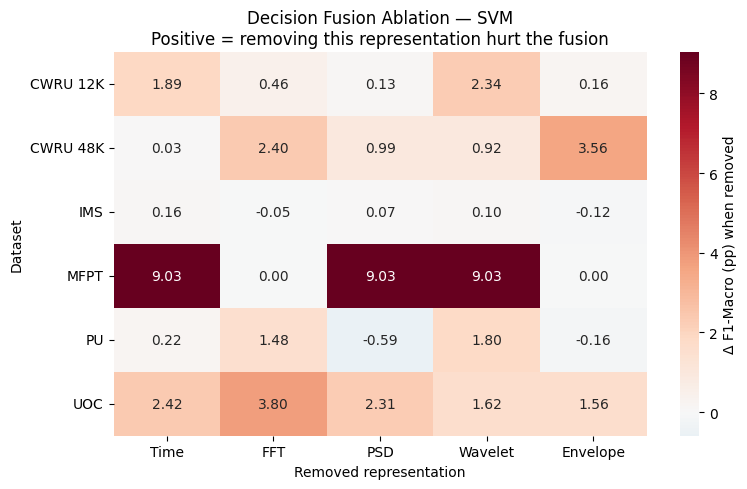

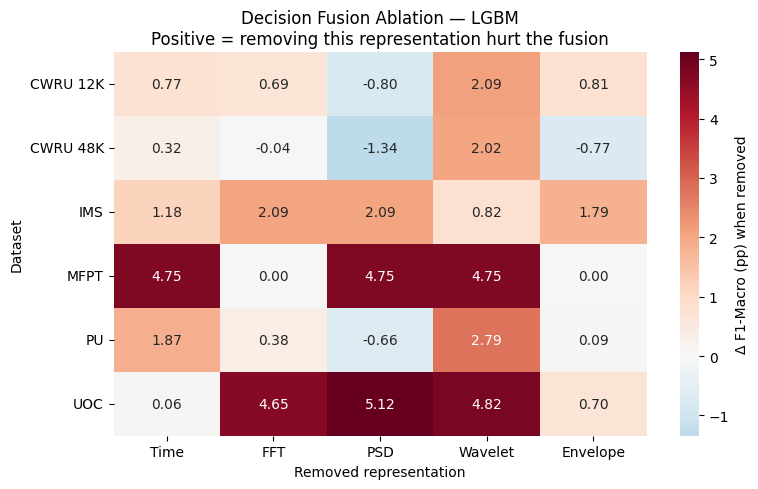

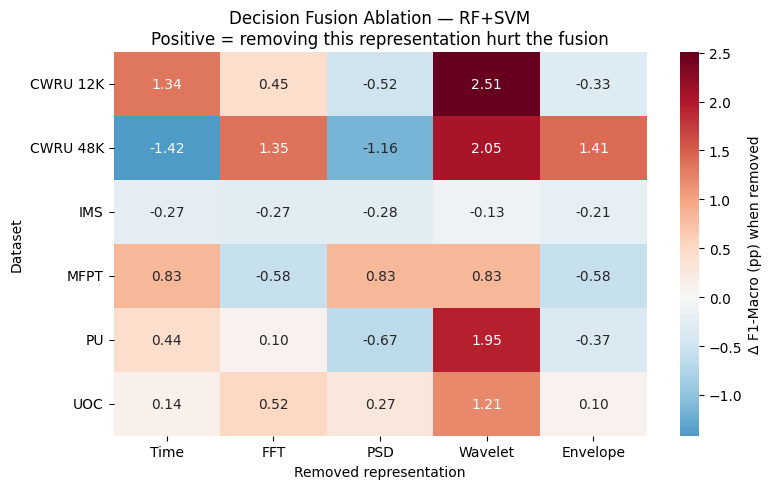

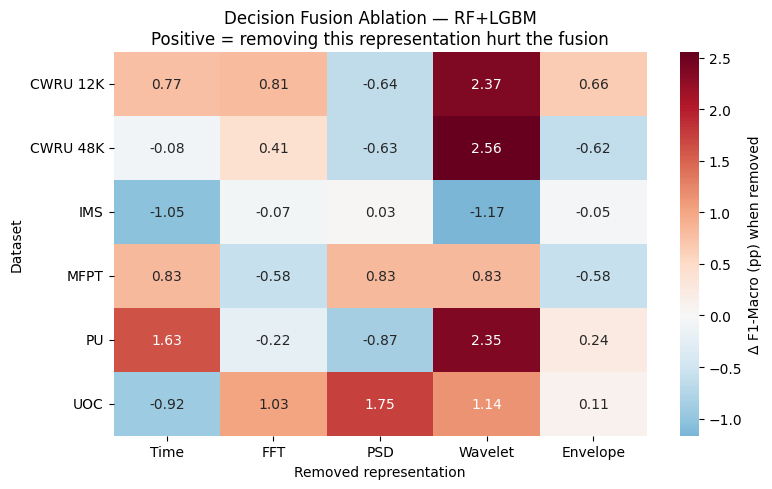

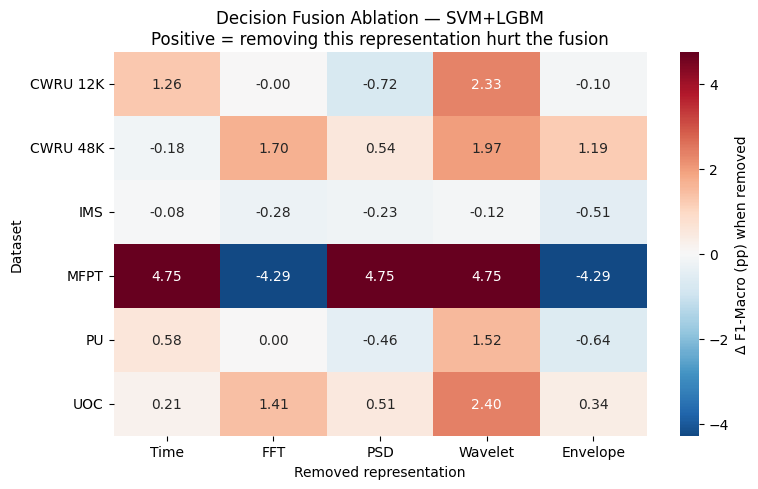

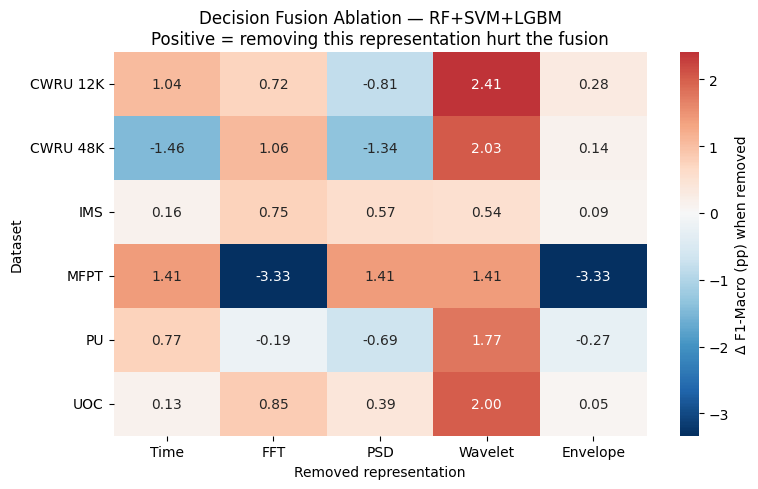

In [89]:
for group_name in fusion_ablation_df["Fusion Group"].unique():
    plot_fusion_ablation_heatmap(fusion_ablation_df, group_name)
